# Goerlitz Household PV Data

General information
- continuous daily data since 2005-05-18
- location: 02827 Goerlitz, Germany
- 3 parties on a single rooftop measured separately
- different number of panels:
    - S: 8 panels
    - W: 14 panels
    - H: 44 panels
- important: measurement device was exchanged (26.08.2021 to 27.08.2012)
    - here: counts start at zero again

Table Content
- relevant data "Gesamt-Leistung" = cumulative energy production
- other columns can be discarded and recalculated

## Preparations

In [1]:
# !pip install missingno

In [2]:
# load required packages
from dateutil import relativedelta
from datetime import datetime
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
import pandas as pd
import numpy as np

## Load data

In [3]:
# read dataframe
df = pd.read_csv("../data/PV_Goerlitz_02827.csv", sep=";", thousands=',')
df.shape

(6630, 10)

In [4]:
# inspect df
df.tail()

,Unnamed: 0,S Gesamt-Leistung,S Leistung pro Platte,S Zuwachs pro Platte & Tag,W Gesamt-Leistung,W Leistung pro Platte,W Zuwachs pro Platte & Tag,H Gesamt-Leistung,H Leistung pro Platte,H Zuwachs pro Platte & Tag
6625,08.07.2023,2413.0,301.6,0.9,4390.0,313.6,1.0,13019.0,295.9,1.0
6626,09.07.2023,2420.0,302.5,0.9,4403.0,314.5,0.9,13062.0,296.9,1.0
6627,10.07.2023,2427.0,303.4,0.9,4414.0,315.3,0.8,13095.0,297.6,0.8
6628,11.07.2023,2433.0,304.1,0.8,4426.0,316.1,0.9,13135.0,298.5,0.9
6629,12.07.2023,2437.0,304.6,0.5,4433.0,316.6,0.5,13158.0,299.0,0.5


## Data preprocessing

In [5]:
# rename columns
df.columns = ('Date', 'S_yield', 'S_yield_per_panel', 'S_y_per_panel_and_day',
       'W_yield', 'W_yield_per_panel', 'W_y_per_panel_and_day', 'H_yield',
       'H_yield_per_panel', 'H_y_per_panel_and_day')

In [6]:
# inspect df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6630 entries, 0 to 6629
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   6630 non-null   object 
 1   S_yield                6630 non-null   float64
 2   S_yield_per_panel      6630 non-null   float64
 3   S_y_per_panel_and_day  6630 non-null   float64
 4   W_yield                6630 non-null   float64
 5   W_yield_per_panel      6630 non-null   float64
 6   W_y_per_panel_and_day  6630 non-null   float64
 7   H_yield                6630 non-null   float64
 8   H_yield_per_panel      6630 non-null   float64
 9   H_y_per_panel_and_day  6630 non-null   float64
dtypes: float64(9), object(1)
memory usage: 518.1+ KB


In [7]:
# check for leading space in date entries that may avoid format conversion to datetime
sorted(df.Date)[:3]

[' 30.04.2008', '01.01.2006', '01.01.2007']

In [8]:
# convert to datetime
df['Date'] = df['Date'].replace(' 30.04.2008', '30.04.2008')
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y')

In [9]:
# inspect df
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,6630,2014-06-14 12:00:00,2005-05-18 00:00:00,2009-11-30 06:00:00,2014-06-14 12:00:00,2018-12-27 18:00:00,2023-07-12 00:00:00,NaN
S_yield,6630.0,9717.178281,4.0,3577.225,9547.45,15226.1,21632.6,6512.694944
S_yield_per_panel,6630.0,1214.653484,0.5,447.125,1193.45,1903.3,2704.1,814.087222
S_y_per_panel_and_day,6630.0,0.455008,0.0,0.2,0.4,0.7,1.2,0.32032
W_yield,6630.0,17919.682534,4.3,6648.1,17702.15,28047.0,39656.8,11958.071565
W_yield_per_panel,6630.0,1279.979849,0.3,474.85,1264.45,2003.375,2832.6,854.14817
W_y_per_panel_and_day,6630.0,0.473997,0.0,0.2,0.5,0.8,1.5,0.331409
H_yield,6630.0,53190.328824,4.3,20510.275,51597.1,82611.425,118276.5,35341.05015
H_yield_per_panel,6630.0,1208.872805,0.1,466.125,1172.65,1877.525,2688.1,803.205314
H_y_per_panel_and_day,6630.0,0.449427,0.0,0.1,0.4,0.7,1.5,0.328087


In [10]:
# drop derived columns
df.drop(columns=['S_yield_per_panel', 'S_y_per_panel_and_day', 
                 'W_yield_per_panel', 'W_y_per_panel_and_day',
                 'H_yield_per_panel', 'H_y_per_panel_and_day'], inplace=True)

In [11]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
Date,6630,2014-06-14 12:00:00,2005-05-18 00:00:00,2009-11-30 06:00:00,2014-06-14 12:00:00,2018-12-27 18:00:00,2023-07-12 00:00:00,NaN
S_yield,6630.0,9717.178281,4.0,3577.225,9547.45,15226.1,21632.6,6512.694944
W_yield,6630.0,17919.682534,4.3,6648.1,17702.15,28047.0,39656.8,11958.071565
H_yield,6630.0,53190.328824,4.3,20510.275,51597.1,82611.425,118276.5,35341.05015


### Derive new features

- (re-)calculate additional columns for higher precision
- here: use number of panels to calculate the yield per panel
    - S: 8 panels
    - W: 14 panels
    - H: 44 panels
- calculations done:
    - daily yield per panel (here: use NaN to correct for counter exchange)
    - total yield per panel


In [12]:
# re-calculate daily yield per panel
df["S_daily_yield_per_panel"] = df.S_yield.diff() / 8
df["W_daily_yield_per_panel"] = df.W_yield.diff() / 14
df["H_daily_yield_per_panel"] = df.H_yield.diff() / 44

Check for incorrect data (production must be >= 0)

In [13]:
df[(df["S_daily_yield_per_panel"]<0) | (df["H_daily_yield_per_panel"]<0) | (df["W_daily_yield_per_panel"]<0)]
# df.query('S_daily_yield_per_panel<0 or W_daily_yield_per_panel<0 or H_daily_yield_per_panel<0')


,Date,S_yield,W_yield,H_yield,S_daily_yield_per_panel,W_daily_yield_per_panel,H_daily_yield_per_panel
5945,2021-08-27,4.0,8.0,26.0,-2703.575,-2832.057143,-2687.511364


In [14]:
# access misc row by index
df.iloc[df[df["W_daily_yield_per_panel"]<-100].index[0]]  

Date                       2021-08-27 00:00:00
S_yield                                    4.0
W_yield                                    8.0
H_yield                                   26.0
S_daily_yield_per_panel              -2703.575
W_daily_yield_per_panel           -2832.057143
H_daily_yield_per_panel           -2687.511364
Name: 5945, dtype: object

In [15]:
# set value to NaN after changing the counting device
df.loc[df.W_daily_yield_per_panel < -100, 'W_daily_yield_per_panel'] = np.nan
df.loc[df.H_daily_yield_per_panel < -100, 'H_daily_yield_per_panel'] = np.nan
df.loc[df.S_daily_yield_per_panel < -100, 'S_daily_yield_per_panel'] = np.nan

In [16]:
df.query('Date > "2021-08-25" and Date < "2021-08-29"')


,Date,S_yield,W_yield,H_yield,S_daily_yield_per_panel,W_daily_yield_per_panel,H_daily_yield_per_panel
5944,2021-08-26,21632.6,39656.8,118276.5,0.0625,0.071429,0.068182
5945,2021-08-27,4.0,8.0,26.0,NaN,NaN,NaN
5946,2021-08-28,7.0,13.0,40.0,0.3750,0.357143,0.318182


In [17]:
# calculate adjusted total production
df['S_yield_adjusted'] = df.S_yield.where(df.Date<"2021-08-27", df.S_yield+max(df.S_yield))
df['H_yield_adjusted'] = df.H_yield.where(df.Date<"2021-08-27", df.H_yield+max(df.H_yield))
df['W_yield_adjusted'] = df.W_yield.where(df.Date<"2021-08-27", df.W_yield+max(df.W_yield))

In [18]:
# check calculation result
df.query('Date > "2021-08-25" and Date < "2021-08-29"')[["S_yield", "S_yield_adjusted", "H_yield", "H_yield_adjusted", "W_yield", "W_yield_adjusted"]]

,S_yield,S_yield_adjusted,H_yield,H_yield_adjusted,W_yield,W_yield_adjusted
5944,21632.6,21632.6,118276.5,118276.5,39656.8,39656.8
5945,4.0,21636.6,26.0,118302.5,8.0,39664.8
5946,7.0,21639.6,40.0,118316.5,13.0,39669.8


In [19]:
df[["S_yield", "S_yield_adjusted", "H_yield", "H_yield_adjusted", "W_yield", "W_yield_adjusted"]].tail(3)

,S_yield,S_yield_adjusted,H_yield,H_yield_adjusted,W_yield,W_yield_adjusted
6627,2427.0,24059.6,13095.0,131371.5,4414.0,44070.8
6628,2433.0,24065.6,13135.0,131411.5,4426.0,44082.8
6629,2437.0,24069.6,13158.0,131434.5,4433.0,44089.8


In [20]:
# calculate total yield per panel
df["S_total_yield_per_panel_adjusted"] = df.S_yield_adjusted / 8
df["W_total_yield_per_panel_adjusted"] = df.W_yield_adjusted / 14
df["H_total_yield_per_panel_adjusted"] = df.H_yield_adjusted / 44

In [21]:
# derive other time columns
df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month
df['Week']=df['Date'].dt.isocalendar().week.astype('int32')
df['Weekday']=df['Date'].dt.dayofweek
df['Dayofyear']=df['Date'].dt.dayofyear

## Data description

In [22]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
Date,6630,2014-06-14 12:00:00,2005-05-18 00:00:00,2009-11-30 06:00:00,2014-06-14 12:00:00,2018-12-27 18:00:00,2023-07-12 00:00:00,NaN
S_yield,6630.0,9717.178281,4.0,3577.225,9547.45,15226.1,21632.6,6512.694944
W_yield,6630.0,17919.682534,4.3,6648.1,17702.15,28047.0,39656.8,11958.071565
H_yield,6630.0,53190.328824,4.3,20510.275,51597.1,82611.425,118276.5,35341.05015
S_daily_yield_per_panel,6628.0,0.453781,0.0,0.15,0.4375,0.725,1.2375,0.316983
W_daily_yield_per_panel,6628.0,0.475014,0.0,0.171429,0.457143,0.757143,1.5,0.328243
H_daily_yield_per_panel,6628.0,0.450582,0.0,0.147159,0.415909,0.725,1.502273,0.324521
S_yield_adjusted,6630.0,11952.220664,4.3,6028.5,11831.6,17860.3,24069.6,6894.116258
H_yield_adjusted,6630.0,65410.449864,4.3,34483.7,64420.2,97402.55,131434.5,37371.849783
W_yield_adjusted,6630.0,22016.953725,4.3,11183.525,21893.4,32829.075,44089.8,12617.293289


Description: Newly calculated daily yields per panel are more precise and exhibits a similar distribution (mean & sd) as the one in the original data file

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6630 entries, 0 to 6629
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Date                              6630 non-null   datetime64[ns]
 1   S_yield                           6630 non-null   float64       
 2   W_yield                           6630 non-null   float64       
 3   H_yield                           6630 non-null   float64       
 4   S_daily_yield_per_panel           6628 non-null   float64       
 5   W_daily_yield_per_panel           6628 non-null   float64       
 6   H_daily_yield_per_panel           6628 non-null   float64       
 7   S_yield_adjusted                  6630 non-null   float64       
 8   H_yield_adjusted                  6630 non-null   float64       
 9   W_yield_adjusted                  6630 non-null   float64       
 10  S_total_yield_per_panel_adjusted  6630 non-null 

## Visualizations

### Yield vs. adjusted yield

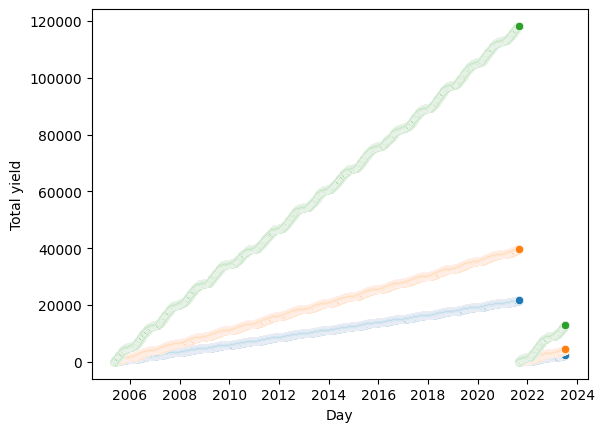

In [24]:
sns.scatterplot(x=df["Date"], y=df["S_yield"])
sns.scatterplot(x=df["Date"], y=df["W_yield"])
sns.scatterplot(x=df["Date"], y=df["H_yield"]).set(ylabel="Total yield", xlabel="Day")
# sns.lineplot(x=df["Date"], y=df["H_yield"])
plt.show()

[Text(0, 0.5, 'Total yield'), Text(0.5, 0, 'Day')]

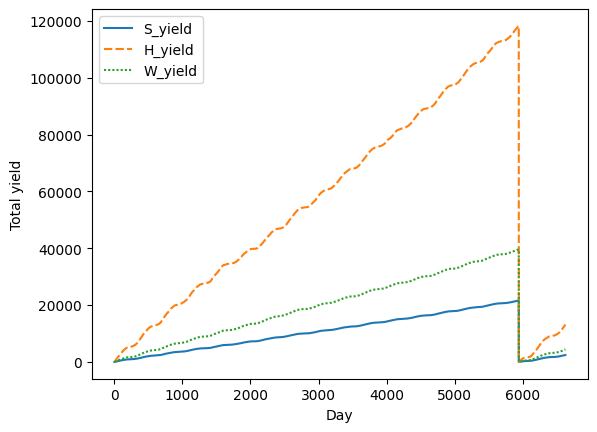

In [25]:
sns.lineplot(df[["Date", "S_yield", "H_yield", "W_yield"]]).set(ylabel="Total yield", xlabel="Day")


[Text(0, 0.5, 'Total yield'), Text(0.5, 0, 'Day')]

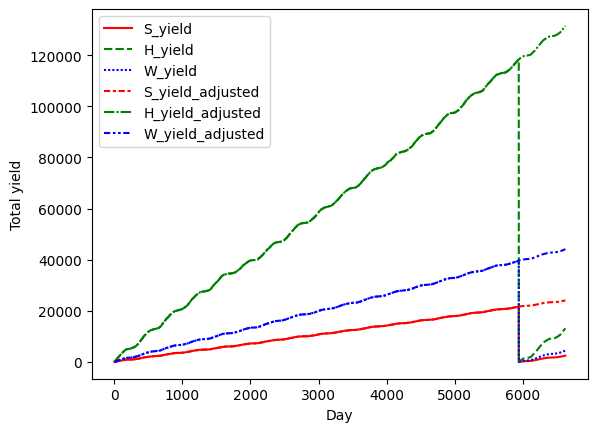

In [26]:
sns.lineplot(df[["Date", "S_yield", "H_yield", "W_yield", 
                 "S_yield_adjusted", "H_yield_adjusted", "W_yield_adjusted"]], 
             palette=["r", "g", "b", "r", "g", "b"]).set(ylabel="Total yield", xlabel="Day")


### Year-wise patterns - daily

[]

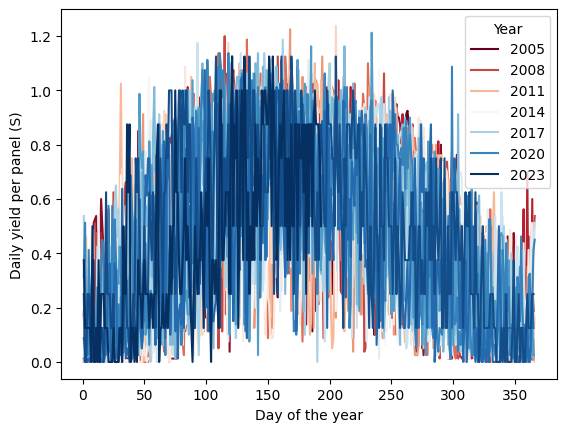

In [27]:
sns.lineplot(data=df, x="Dayofyear", y="S_daily_yield_per_panel", hue="Year", palette="RdBu")\
    .set(ylabel="Daily yield per panel (S)", xlabel="Day of the year")
plt.plot()


[]

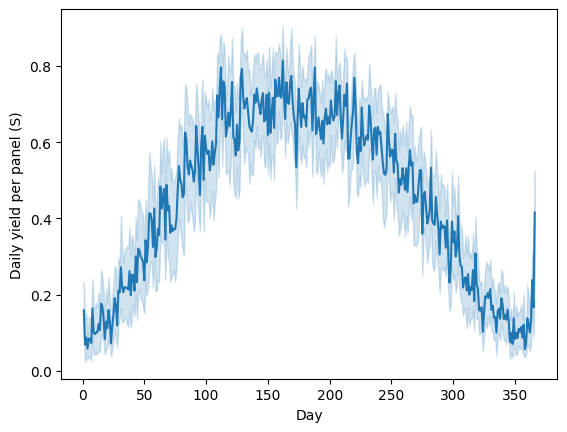

In [28]:
sns.lineplot(data=df, x="Dayofyear", y="S_daily_yield_per_panel").set(ylabel="Daily yield per panel (S)", xlabel="Day")
plt.plot()


[]

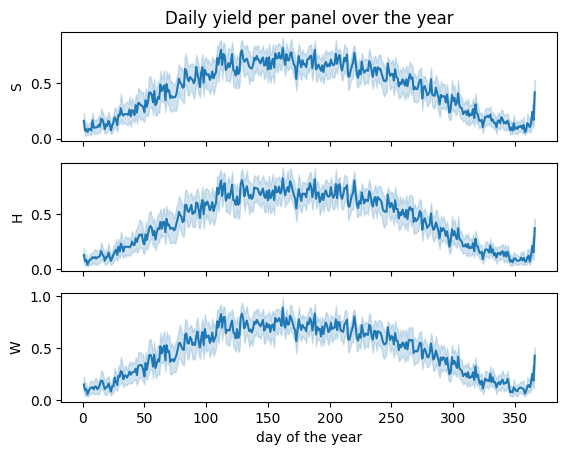

In [29]:
fig, ax = plt.subplots(3,1, sharex=True)
sns.lineplot(data=df, x="Dayofyear", y="S_daily_yield_per_panel", ax=ax[0]).set(ylabel="S", xlabel="day of the year", title="Daily yield per panel over the year")
sns.lineplot(data=df, x="Dayofyear", y="H_daily_yield_per_panel", ax=ax[1]).set(ylabel="H", xlabel="day of the year")
sns.lineplot(data=df, x="Dayofyear", y="W_daily_yield_per_panel", ax=ax[2]).set(ylabel="W", xlabel="day of the year")
plt.plot()


### Year-wise patterns - weekly

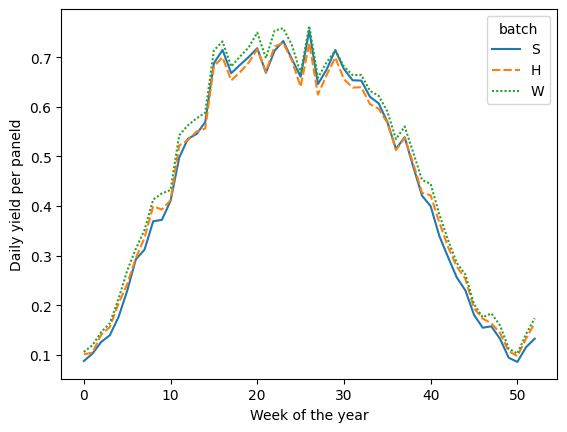

In [30]:
fig = sns.lineplot(data=pd.DataFrame(np.array(pd.pivot_table(data=df, columns="Week", 
                                                             values=["S_daily_yield_per_panel", 
                                                                     "H_daily_yield_per_panel", 
                                                                     "W_daily_yield_per_panel"],
                                                             aggfunc=np.mean).T)))
fig.set(ylabel="Daily yield per paneld", xlabel="Week of the year")

# add labels
leg = fig.axes.get_legend()
leg.set_title('batch')
new_labels = ['S', 'H', 'W']
for t, l in zip(leg.texts, new_labels):
    t.set_text(l)
plt.show()


[]

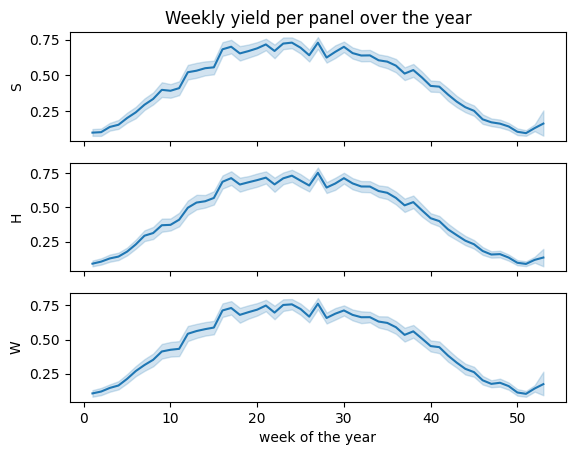

In [31]:
fig, ax = plt.subplots(3,1, sharex=True)
sns.lineplot(data=df, x="Week", y="S_daily_yield_per_panel", ax=ax[0]).set(ylabel="S", xlabel="week of the year", title="Weekly yield per panel over the year")
sns.lineplot(data=df, x="Week", y="H_daily_yield_per_panel", ax=ax[1]).set(ylabel="H", xlabel="week of the year")
sns.lineplot(data=df, x="Week", y="W_daily_yield_per_panel", ax=ax[2]).set(ylabel="W", xlabel="week of the year")
plt.plot()


### Overall patterns - monthly

In [32]:
gbo = df.groupby(["Year", "Month"]).mean().reset_index()
gbo.head(3)

,Year,Month,Date,S_yield,W_yield,H_yield,S_daily_yield_per_panel,W_daily_yield_per_panel,H_daily_yield_per_panel,S_yield_adjusted,H_yield_adjusted,W_yield_adjusted,S_total_yield_per_panel_adjusted,W_total_yield_per_panel_adjusted,H_total_yield_per_panel_adjusted,Week,Weekday,Dayofyear
0,2005,5,2005-05-24 12:00:00,43.571429,77.435714,230.871429,0.771154,0.819780,0.814336,43.571429,230.871429,77.435714,5.446429,5.531122,5.247078,20.785714,3.000000,144.5
1,2005,6,2005-06-15 12:00:00,166.226667,306.270000,949.706667,0.708333,0.753810,0.752955,166.226667,949.706667,306.270000,20.778333,21.876429,21.584242,23.933333,2.966667,166.5
2,2005,7,2005-07-16 00:00:00,329.409677,609.170968,1901.841935,0.626613,0.662673,0.661804,329.409677,1901.841935,609.170968,41.176210,43.512212,43.223680,28.258065,3.193548,197.0


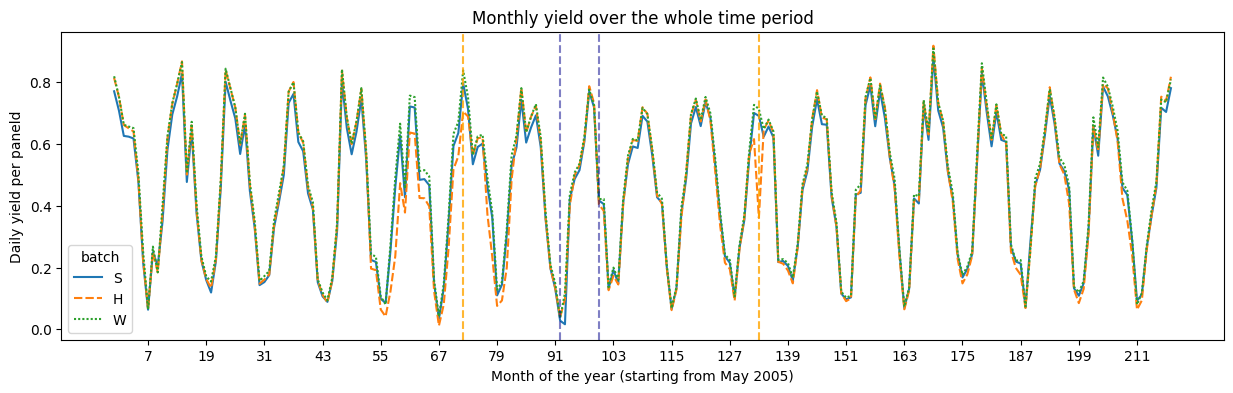

In [33]:
plt.subplots(figsize=(15,4))
fig = sns.lineplot(data=gbo[["S_daily_yield_per_panel", "H_daily_yield_per_panel", "W_daily_yield_per_panel"]])
fig.set(ylabel="Daily yield per paneld", xlabel="Month of the year (starting from May 2005)")
fig.set_xticks(range(7, len(gbo), 12))
fig.set_title("Monthly yield over the whole time period")

# add labels
leg = fig.axes.get_legend()
leg.set_title('batch')
new_labels = ['S', 'H', 'W']
for t, l in zip(leg.texts, new_labels):
    t.set_text(l)


# draw lines for repair dates - x = number of months in operation (to calculate)
# list of repairs for the different parties
repair_dates_H = [datetime(2011, 6, 8), datetime(2016, 6, 26)]
repair_dates_S = [datetime(2013, 2, 16), datetime(2013, 10, 16)]

# starting date for operation
start_date = df.Date.min()

# calculate number of months in operation
x_H = []
x_S = []
for date_list, target_list in [[repair_dates_H, x_H], [repair_dates_S, x_S]]:
    for end_date in date_list:
        # time duration from operation start to repair
        delta = relativedelta.relativedelta(end_date, start_date)
        # number of months as x value
        months = delta.months + delta.years*12
        target_list.append(months)

for item in x_H:
    plt.axvline(x=item, color="orange", linestyle="--", alpha=0.8)
for item in x_S:
    plt.axvline(x=item, color="darkblue", linestyle="--", alpha=0.5)

plt.show()


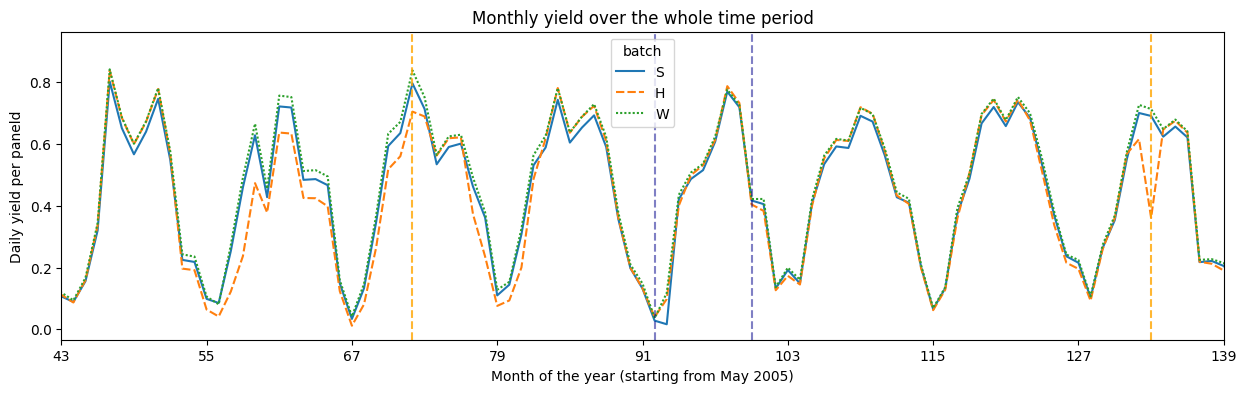

In [34]:
plt.subplots(figsize=(15,4))
fig = sns.lineplot(data=gbo[["S_daily_yield_per_panel", "H_daily_yield_per_panel", "W_daily_yield_per_panel"]])
fig.set(ylabel="Daily yield per panel", xlabel="Month of the year (starting from May 2005)")
fig.set_xticks(range(7, len(gbo), 12))
fig.set_title("Monthly yield over the whole time period")

# add labels
leg = fig.axes.get_legend()
leg.set_title('batch')
new_labels = ['S', 'H', 'W']
for t, l in zip(leg.texts, new_labels):
    t.set_text(l)

for item in x_H:
    plt.axvline(x=item, color="orange", linestyle="--", alpha=0.8)
for item in x_S:
    plt.axvline(x=item, color="darkblue", linestyle="--", alpha=0.5)

fig.set_xlim(43, 139)

plt.show()


## Python environment

In [36]:
!pip freeze

aiofiles==22.1.0
aiosqlite==0.19.0
alembic==1.11.1
anyio==3.7.1
appnope==0.1.3
argon2-cffi==21.3.0
argon2-cffi-bindings==21.2.0
arrow==1.2.3
asttokens==2.2.1
attrs==23.1.0
Babel==2.12.1
backcall==0.2.0
beautifulsoup4==4.12.2
black==23.3.0
bleach==6.0.0
blinker==1.6.2
bs4==0.0.1
certifi==2023.5.7
cffi==1.15.1
chardet==5.1.0
charset-normalizer==3.2.0
click==8.1.5
cloudpickle==2.2.1
comm==0.1.3
contourpy==1.1.0
cycler==0.11.0
dacite==1.8.1
databricks-cli==0.17.7
debugpy==1.6.7
decorator==5.1.1
defusedxml==0.7.1
docker==6.1.3
entrypoints==0.4
executing==1.2.0
fastjsonschema==2.17.1
Flask==2.3.2
fonttools==4.41.0
fqdn==1.5.1
gitdb==4.0.10
GitPython==3.1.32
gunicorn==20.1.0
htmlmin==0.1.12
idna==3.4
ImageHash==4.3.1
importlib-metadata==6.8.0
iniconfig==2.0.0
ipykernel==6.24.0
ipython==8.14.0
ipython-genutils==0.2.0
isoduration==20.11.0
itsdangerous==2.1.2
jedi==0.18.2
Jinja2==3.1.2
joblib==1.3.1
json5==0.9.14
jsonpointer==2.4
jsonschema==4.18.3
jsonschema-specifications==2023.6.1
jupyter-eve

## Data Structure

Column | Content
--- | ---
._yield | total yield (measured)
._daily_yield_per_panel | daily yield per panel (calculated)
._yield_adjusted | total yield (summed up after new device)
._total_yield_per_panel_adjusted | total yield per panel (calculated)
Date | 
Year | 
Month | 
Week | 
Weekday | 
Dayofyear | 


## Summary

- data well comparable among the 3 parties
    - identical age
    - identical technology
    - identical location and conditions
- events of damage and repair apparent from the data graph
    - clear indication for importance of early alerts in case of reduced energy generation

In [37]:
# !pip install --upgrade numpy
# !pip install --upgrade seaborn

In [38]:
# # prevent error with sns lineplot: OptionError: No such keys(s): 'mode.use_inf_as_null' 
# # conflict between numpy==1.24.3 and seaborn==0.11.2 (matplotlib==3.7.1; pandas==2.0.1)
# # !pip install numpy==1.25.0
# !pip install numpy==1.23.5
# !pip install seaborn==0.12.2
# !pip install pandas==2.0.2
# # issue with empty lineplot still persistent